# Étape 2 — Augmentation des données (Albumentations — `pill`)

TP B6, partie 1. Pipeline appliqué uniquement aux images **saines d'entraînement**.

In [1]:
from pathlib import Path

import albumentations as A
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from indusense.vision.augment import augment_image, build_augmentation_pipeline, describe_replay
from indusense.vision.dataset import DEFAULT_IMAGE_SIZE, load_good_images

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

good_train = load_good_images("train", DEFAULT_IMAGE_SIZE)
pipeline = build_augmentation_pipeline()
original = good_train[0]

## Démonstration isolée des transformations de l'énoncé

L'énoncé du TP liste quatre familles de transformations : **flips, rotations légères, translation/échelle, variations d'éclairage**. Chacune est forcée ici individuellement (`p=1`, une seule transformation à la fois) pour observer son effet propre sur la gravure « FF » — y compris le **flip**, volontairement **exclu du pipeline réel** (`augment.py`), montré ici comme preuve visuelle du problème de miroir (cf. justification plus bas).

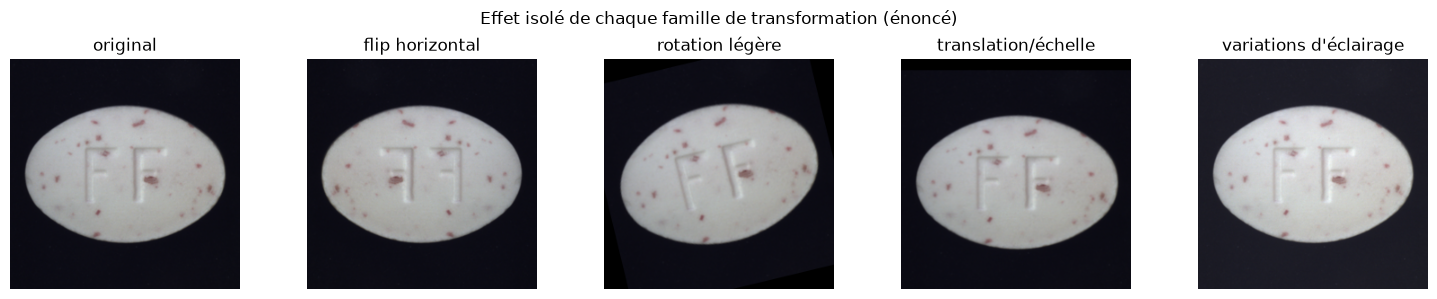

- **flip horizontal** : flip horizontal (miroir gauche/droite)
- **rotation légère** : rotation +13.6°
- **translation/échelle** : translation (-0.0 %, +4.8 %), échelle (×1.01, ×0.97)
- **variations d'éclairage** : contraste ×1.09, luminosité +0.06

In [2]:
demo_transforms = {
    "flip horizontal": A.ReplayCompose([A.HorizontalFlip(p=1.0)]),
    "rotation légère": A.ReplayCompose([A.Rotate(limit=15, border_mode=0, p=1.0)]),
    "translation/échelle": A.ReplayCompose(
        [A.Affine(translate_percent=(-0.05, 0.05), scale=(0.95, 1.05), border_mode=0, p=1.0)]
    ),
    "variations d'éclairage": A.ReplayCompose(
        [A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=1.0)]
    ),
}

demo_results = {name: tf(image=original) for name, tf in demo_transforms.items()}

fig, axes = plt.subplots(1, len(demo_results) + 1, figsize=(3 * (len(demo_results) + 1), 3))
axes[0].imshow(original)
axes[0].set_title("original")
axes[0].axis("off")
for i, (name, result) in enumerate(demo_results.items(), start=1):
    axes[i].imshow(result["image"])
    axes[i].set_title(name)
    axes[i].axis("off")
fig.suptitle("Effet isolé de chaque famille de transformation (énoncé)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_transformations_isolees.png", dpi=150)
plt.show()

lines = [f"- **{name}** : {describe_replay(result['replay'])}" for name, result in demo_results.items()]
display(Markdown(chr(10).join(lines)))

## Livrable — original vs versions augmentées (pipeline réel, 8 tirages aléatoires)

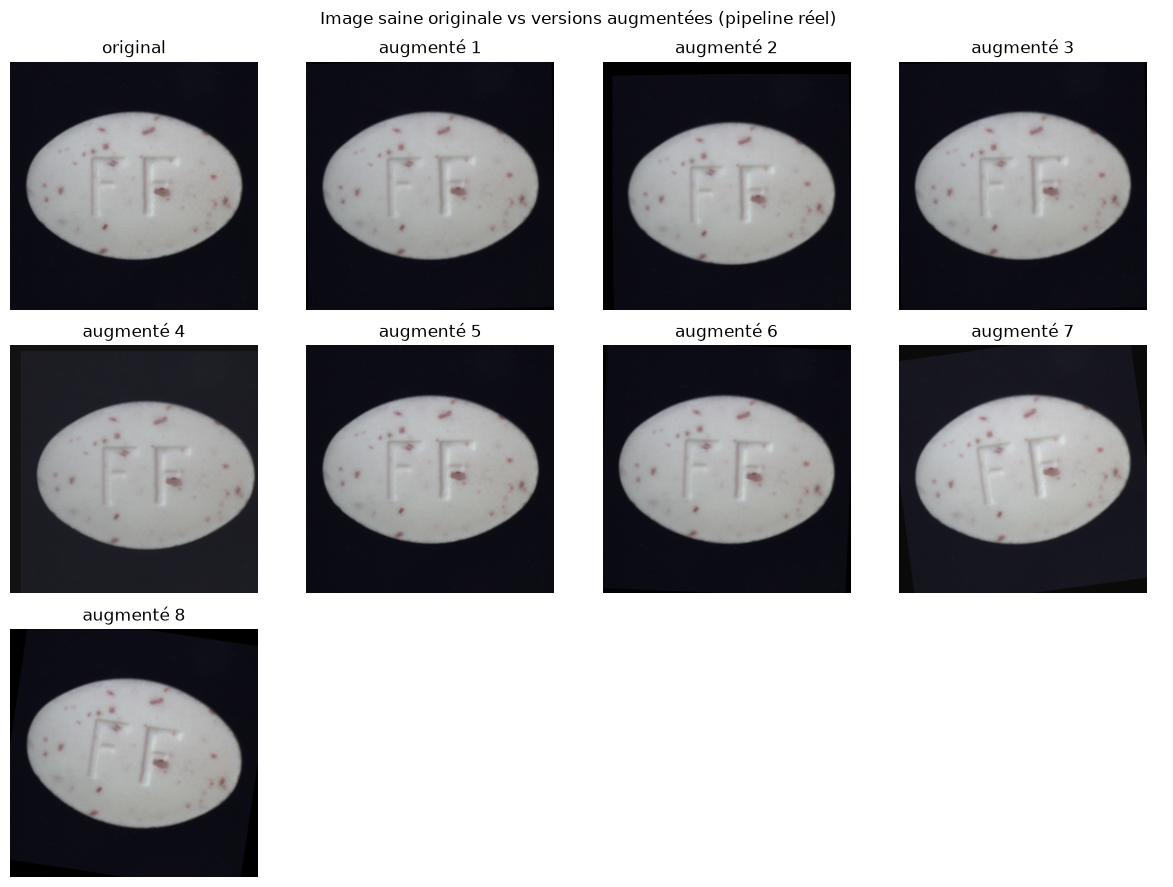

- **augmentation 1** : rotation +1.2°; contraste ×0.98, luminosité -0.00
- **augmentation 2** : rotation +0.7°; translation (+4.0 %, +5.0 %), échelle (×0.96, ×0.96)
- **augmentation 3** : rotation +1.2°
- **augmentation 4** : translation (+4.2 %, +2.4 %), échelle (×1.01, ×1.00); contraste ×0.87, luminosité +0.07
- **augmentation 5** : aucune transformation tirée (probabilités défavorables)
- **augmentation 6** : rotation -2.4°
- **augmentation 7** : rotation +7.8°; contraste ×1.02, luminosité +0.04
- **augmentation 8** : rotation -8.5°

In [3]:
n_variants = 8
results = augment_image(original, pipeline, n=n_variants)
variants = [r["image"] for r in results]
descriptions = [describe_replay(r["replay"]) for r in results]

n_cols = 4
n_rows = -(-(n_variants + 1) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = axes.flatten()
axes[0].imshow(original)
axes[0].set_title("original")
axes[0].axis("off")
for i, variant in enumerate(variants, start=1):
    axes[i].imshow(variant)
    axes[i].set_title(f"augmenté {i}")
    axes[i].axis("off")
for ax in axes[n_variants + 1 :]:
    ax.axis("off")
fig.suptitle("Image saine originale vs versions augmentées (pipeline réel)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_augmentations.png", dpi=150)
plt.show()

lines = [f"- **augmentation {i}** : {desc}" for i, desc in enumerate(descriptions, start=1)]
display(Markdown(chr(10).join(lines)))

## Justification des transformations retenues (et écartées)

`pill` est un objet **centré et aligné** (comme `bottle`), pas une texture : chaque image
montre une pilule unique, cadrée de façon quasi identique par la caméra industrielle, avec
une gravure « FF » embossée sur la surface.

**Retenues, amplitudes modérées** :
- **Rotation légère (±15°) et translation/échelle modérées (±5 %)** : imite les petites
  variations de positionnement de la pièce sur la ligne, sans dépasser ce qu'une caméra
  fixe observerait réellement. Une rotation, contrairement à un flip, ne mirroir pas le
  texte : la gravure reste lisible, seulement inclinée.
- **Variations de luminosité/contraste modérées** : reproduit les variations d'éclairage
  industriel (heure, usure des lampes) sans changer la texture de la pilule elle-même.

**Écartées** :
- **Flips horizontal/vertical** : *écartés après relecture des caractéristiques de la
  section 2 du notebook 01*. Une première version du pipeline les incluait, en supposant
  qu'une pilule vue de dessus reste plausible retournée. C'est faux : la gravure « FF »
  n'est pas symétrique, et un flip en inverse la lecture en miroir — la démonstration
  isolée plus haut rend le problème directement visible sur la gravure. Une configuration
  qu'aucune caméra fixe ne peut observer en réalité (retourner l'image 2D n'équivaut pas à
  retourner la pièce physique, qui montrerait alors une autre face, pas un miroir de la
  face imprimée). Un flip produit donc une image saine **impossible**, pas une variation
  plausible.
- **Rotation forte (proche de 180° ou aléatoire sur 360°)** : sur un objet aligné, une
  rotation trop forte élargit artificiellement la notion de « normal » que l'auto-encodeur
  doit apprendre. Le risque direct : un défaut réel (ex. `crack`), une fois « caché » dans
  une orientation inhabituelle mais couverte par l'augmentation, serait bien reconstruit par
  le modèle — donc **non détecté**. C'est l'inverse de l'effet recherché.
- **Distorsions élastiques / déformations fortes** : pertinentes pour des textures
  (tissus, surfaces irrégulières) où la déformation locale ne change pas la nature de
  l'objet, mais inadaptées ici : la forme et les bords nets de la pilule sont eux-mêmes
  des indices de défaut (`crack`, `scratch`) qu'il ne faut pas brouiller.

**Point de réflexion (objet vs texture)** : sur une catégorie *texture* (ex. `carpet`,
`wood`), une augmentation géométrique forte (rotation libre, flip, crop aléatoire) est
généralement acceptable — la texture est localement invariante par rotation/réflexion.
Sur un objet *centré et aligné* portant un repère directionnel (texte, logo) comme `pill`,
toute transformation qui inverse la chiralité de l'image (flip) est à proscrire, et
l'augmentation géométrique restante doit rester modérée sous peine d'élargir la notion de
« normal » au point de masquer les défauts recherchés.

**Point de réflexion (rotation forte, 180°)** : le pipeline retenu limite la rotation
à ±15° et exclut délibérément les rotations proches de 180° (cf. ci-dessus, risque
d'élargir excessivement la notion de « normal »). Cette exclusion repose sur une
hypothèse implicite — que la pilule sort toujours de la chaîne de fabrication dans une
orientation à peu près constante — qui n'a pas été vérifiée. **À valider avec le
métier** : si le poste d'inspection peut réellement recevoir des pilules présentées à
180° (convoyeur ou système d'alimentation qui ne garantit pas une orientation unique),
alors ce ne serait pas une aberration mais une variation réelle du process. Une rotation
à 180°, contrairement à un flip, ne mirroir pas la gravure (elle reste lisible, juste
tête en bas) : elle n'a donc pas le défaut rédhibitoire identifié plus haut pour les
flips. Si le métier confirme que cette orientation existe en sortie de chaîne, il
faudrait reconsidérer la limite de ±15° — quitte à accepter le compromis avec le risque
de masquage de défauts déjà discuté, à arbitrer sur la base de la réalité du poste
d'inspection plutôt que sur un critère statistique seul.